In [67]:
import requests
import pandas as pd
import sys
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from matplotlib.colors import LinearSegmentedColormap
pio.renderers.default = 'notebook'
%matplotlib inline

In [49]:
API_URL = "http://127.0.0.1:8000/"

payload = {  
            'order_frequency': 25,
            'total_monetary_value': -850,
            'total_quantity_abs': 10,
            'total_order_issues': 8,
            'country': 'Germany',
            'avg_order_value': -850,
            'avg_quantity_per_order': 250,
            'customer_order_issue_rate': 13,
            'recency': 25,
            'tenure': 97,
            'avg_stockcode_issue_rate' : 1,
            'max_stockcode_issue_rate': 1.02,
            'total_orders_made_for_stock': 195
            }

In [50]:
response = requests.post(f"{API_URL}/predict_single_feature", json=payload)
results = response.json()

In [72]:
# contributions = results['shap_values']
# sorted_contrib = sorted(contributions, key=lambda x: abs(x['shap_value']), reverse=True)
# features = [c['feature'] for c in sorted_contrib]
# values = [c['shap_value'] for c in sorted_contrib]

In [73]:
# fig = px.bar(x=features, y=values, title="SHAP Values")
# fig.show()

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd

def plot_shap_explanation(shap_contributions, prediction_results, customer_id=None):
    """
    shap_contributions: list of dicts [{'feature': str, 'value': any, 'shap_value': float}]
    prediction_result: dict from your Prediction class, e.g. 
        {'prediction_probability': 0.44, 'prediction': 'Stay', 'risk_label': 'No Risk'}
    customer_id: optional customer identifier
    """
    # Sort by absolute SHAP value descending
    sorted_contrib = sorted(shap_contributions, key=lambda x: abs(x['shap_value']), reverse=True)
    features = [c['feature'] for c in sorted_contrib]
    shap_values = [c['shap_value'] for c in sorted_contrib]
    customer_vals = [c['value'] for c in sorted_contrib]

    # Colors: positive = red (#b11346), negative = green (#0e7337)
    colors = ['#0e7337' if v < 0 else '#b11346' for v in shap_values]

    # Create figure with two rows (2:1 height ratio)
    fig = plt.figure(figsize=(12, 8))
    gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.3)

    # ===== TOP ROW: SHAP bar chart =====
    ax1 = fig.add_subplot(gs[0])
    y_pos = np.arange(len(features))
    bar_height = 0.7
    ax1.barh(y_pos, shap_values, height=bar_height, color=colors)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(features, fontsize=11)
    ax1.set_xlabel('SHAP Value (Impact on Prediction)', fontsize=12)
    ax1.axvline(0, color='black', lw=0.8, alpha=0.5)
    ax1.grid(axis='x', linestyle='--', alpha=0.3)
    ax1.set_title('Feature Impact on Churn Prediction', fontsize=14)

    # ===== BOTTOM ROW: Table =====
    ax2 = fig.add_subplot(gs[1])
    ax2.axis('off')

    # Prepare table data: Feature, Customer Value, SHAP Value
    table_data = [[f, str(v), f"{sv:.4f}"] for f, v, sv in zip(features, customer_vals, shap_values)]
    col_labels = ["Feature", "Customer Value", "SHAP Value"]

    # Color mapping for table cells based on SHAP value (gradient)
    cmap = LinearSegmentedColormap.from_list('impact_cmap', ["#0e7337", "white", "#b11346"])
    max_abs = max(abs(v) for v in shap_values) if shap_values else 1
    norm_vals = [v / max_abs for v in shap_values]
    cell_colors = [[cmap(0.5 + 0.5 * n) for _ in range(3)] for n in norm_vals]  # same color across row

    table = ax2.table(
        cellText=table_data,
        colLabels=col_labels,
        loc='center',
        cellLoc='center',
        colWidths=[0.5, 0.3, 0.2],
        cellColours=cell_colors
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)

    # Style header row
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f0f0f0')

    # ===== TITLE =====
    pred_label = prediction_results['prediction']   # 'Churn' or 'Stay'
    prob = prediction_results['prediction_probability']
    # Show probability of the predicted class
    if pred_label == 'Churn':
        prob_display = prob
    else:
        prob_display = 1 - prob
    title = f"Customer {'ID: ' + str(customer_id) if customer_id else ''} – Prediction: {pred_label} (Probability: {prob_display:.2%} chance the customer will {'leave' if pred_label == 'Churn' else 'stay'})"
    fig.suptitle(title, fontsize=14, y=0.98)

    # plt.tight_layout()
    return fig

In [83]:
prediction_results = results['prediction_results'][0]
shap_contributions = results['shap_values']

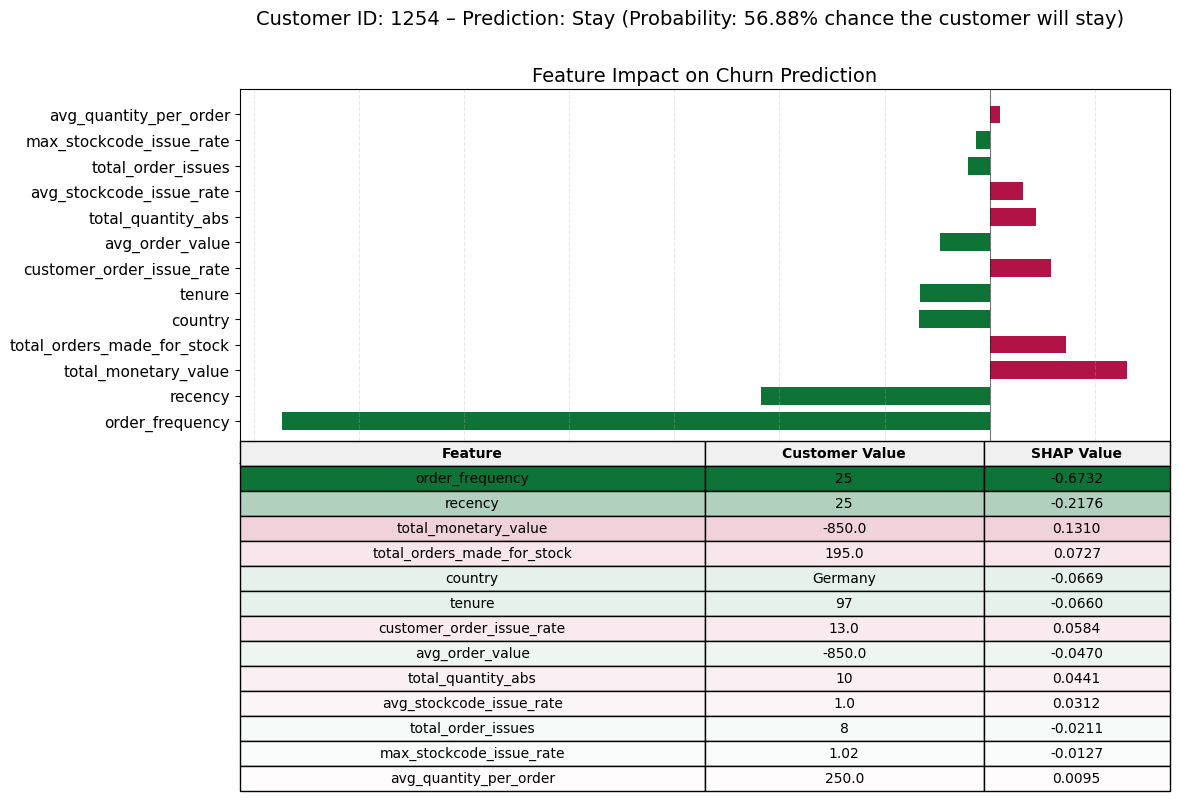

In [84]:
fig = plot_shap_explanation(shap_contributions, prediction_results=prediction_results, customer_id=1254)